# Phase 2: Storage Matching — Generalization to Other Dams (1981)

**Goal:** Test whether the bi-weekly target-tracking model can fit storage
observations at dams other than Moore Dam, by independently optimizing
parameters for each dam from scratch.

Each dam gets its own 20-seed multi-start optimization. Results are
compared across dams using RMSE, NSE, and Bias to assess how well
the model structure generalizes.

**Dams:** Comerford, Bellows Falls, Wilder (all tested in 1981)

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Find the project root so this notebook can run on other computers after cloning from GitHub.
# Expected structure: project_root/LM_26/...
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "LM_26":
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    while not (PROJECT_ROOT / "LM_26").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "LM_26").exists():
    raise FileNotFoundError(
        "Could not find the LM_26 folder. Open VS Code from the project root "
        "or update PROJECT_ROOT manually."
    )

sys.path.insert(0, str(PROJECT_ROOT))

PACKAGE_DIR = PROJECT_ROOT / "LM_26"
INPUT_DIR = PACKAGE_DIR / "experiment_inputs"
OUTPUT_DIR = PACKAGE_DIR / "experiment_outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
PARAM_DIR = OUTPUT_DIR / "params"

# Create output folders only if you later choose to save results/figures.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PARAM_DIR.mkdir(parents=True, exist_ok=True)

from LM_26 import load_dam_data, run_multistart, run_scan, compute_metrics

## 1. Configuration

In [2]:
DAM_CONFIGS = {
    "Comerford": INPUT_DIR / "Comerford_1981_converted_MCM.csv",
    "BellowsFalls": INPUT_DIR / "BellowsFalls_1981_converted_MCM.csv",
    "Wilder": INPUT_DIR / "Wilder_1981_converted_MCM.csv",
}

OPT_SETTINGS = dict(
    num_runs = 20,
    learning_rate = 1e-2,
    num_iterations = 20000,
    lam_smooth = 0.02,
    verbose = False
)

## 2. Per-Dam Optimization

In [ ]:
results = {}

for dam_name, file_path in DAM_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"Optimizing: {dam_name}")
    print(f"{'='*55}")

    data, storage_obs, inflow, biweek_of_year, Smax = load_dam_data(file_path)

    best_params, all_runs, summary = run_multistart(
        inflow_data = inflow,
        storage_obs_data = storage_obs,
        biweek_data = biweek_of_year,
        Smax = Smax,
        **OPT_SETTINGS
    )

    # Save best parameters for this dam
    save_path = PARAM_DIR / f"best_params_{dam_name.lower()}.npy"
    np.save(save_path, np.array(best_params))
    print(f"Saved: {save_path}")

    # Simulate with best parameters
    S_sim, Q_out = run_scan(inflow, storage_obs[0], biweek_of_year, best_params, Smax)
    metrics = compute_metrics(S_sim, storage_obs)

    results[dam_name] = {
        "data": data,
        "storage_obs": storage_obs,
        "S_sim": S_sim,
        "Q_out": Q_out,
        "best_params": best_params,
        "all_runs": all_runs,
        "summary": summary,
        "metrics": metrics,
        "Smax": Smax,
    }

    print(f"RMSE: {metrics['rmse']:.4f} MCM")
    print(f"NSE: {metrics['nse']:.4f}")
    print(f"Bias: {metrics['bias_pct']:+.2f}%")


Optimizing: Comerford
Loaded 365 days from: /Users/liyingma/MEng_Project/LM_26/experiment_inputs/Comerford_1981_converted_MCM.csv
S0 = 36.40 MCM
Smax = 39.80 MCM  (proxy from observed max)
Mean inflow = 8.30 MCM/day

===== Run 1/20 (seed=0) =====
Early stopping at iteration 18576 (best loss = 0.263462 at iter 17576)
Final loss: 0.263462
Final RMSE: 0.5894 MCM
Best iteration: 17576
Iterations run: 18577

===== Run 2/20 (seed=1) =====
Early stopping at iteration 17787 (best loss = 0.263855 at iter 16787)
Final loss: 0.263855
Final RMSE: 0.5911 MCM
Best iteration: 16787
Iterations run: 17788

===== Run 3/20 (seed=2) =====
Early stopping at iteration 17655 (best loss = 0.264320 at iter 16655)
Final loss: 0.264320
Final RMSE: 0.5921 MCM
Best iteration: 16655
Iterations run: 17656

===== Run 4/20 (seed=3) =====
Early stopping at iteration 7864 (best loss = 0.280930 at iter 6864)
Final loss: 0.280930
Final RMSE: 0.6014 MCM
Best iteration: 6864
Iterations run: 7865

===== Run 5/20 (seed=4) ==

## 3. Summary Table

In [4]:
rows = []
for dam_name, r in results.items():
    rows.append({
        "Dam":        dam_name,
        "RMSE (MCM)": round(r["metrics"]["rmse"],     4),
        "NSE":        round(r["metrics"]["nse"],      4),
        "Bias (%)": round(r["metrics"]["bias_pct"], 2),
        "Best Seed":  r["summary"]["best_seed"],
    })

df_summary = pd.DataFrame(rows).set_index("Dam")
print(df_summary.to_string())
# df_summary.to_csv(OUTPUT_DIR / "other_dams_metrics.csv")

              RMSE (MCM)     NSE  Bias (%)  Best Seed
Dam                                                  
Comerford         0.5903  0.9863     -0.10          5
BellowsFalls      1.2455  0.9810     -0.12          6
Wilder            1.5795  0.9850     -0.08          2


## 4. Storage Matching Plots

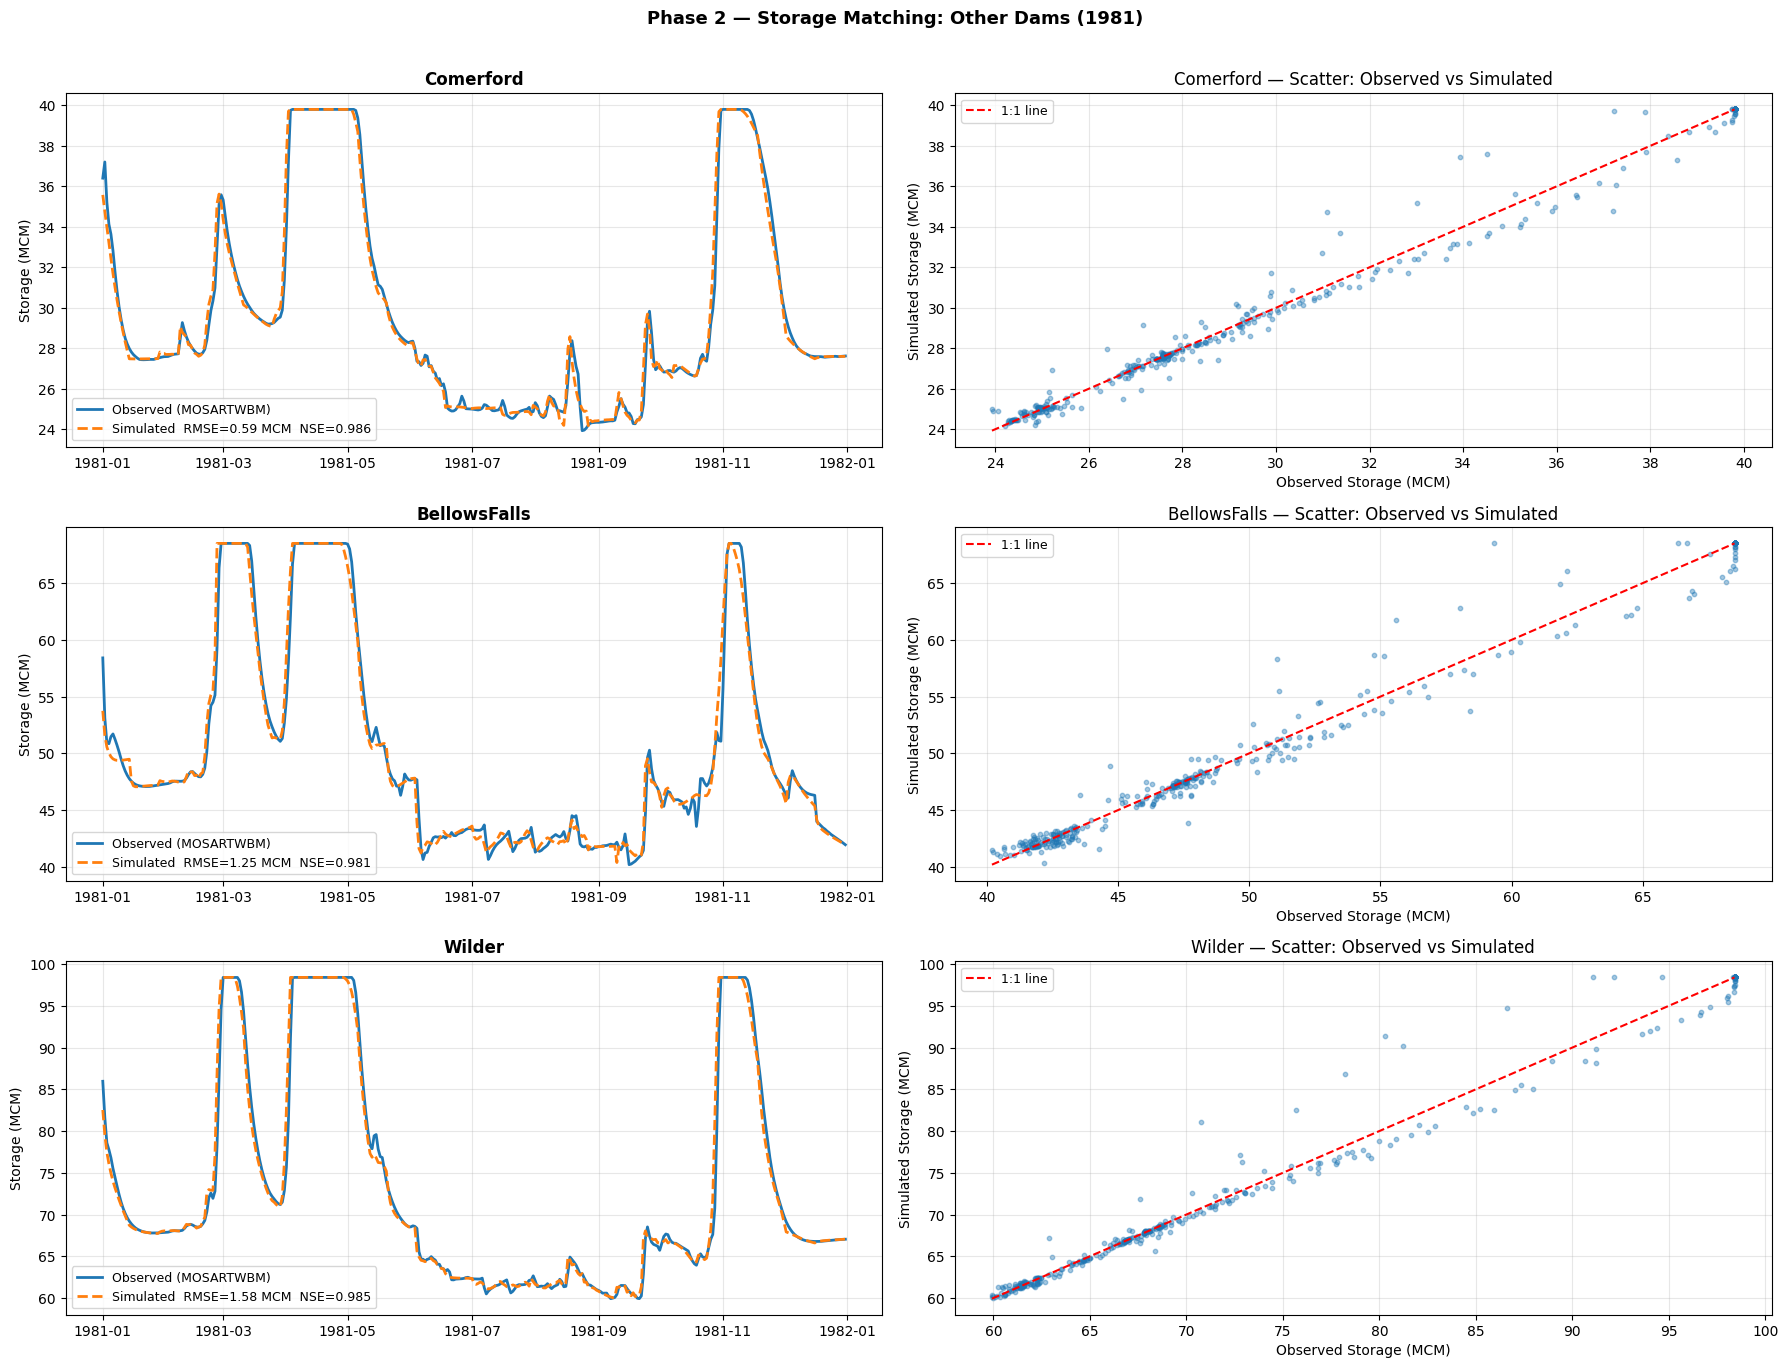

In [10]:
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(18, 4.5 * n))

if n == 1:
    axes = axes.reshape(1, -1)

for row_idx, (dam_name, r) in enumerate(results.items()):
    m = r["metrics"]

    # --- Time series ---
    ax_ts = axes[row_idx, 0]
    ax_ts.plot(r["data"]["time"], np.array(r["storage_obs"]),
               label="Observed (MOSARTWBM)", linewidth=2)
    ax_ts.plot(r["data"]["time"], np.array(r["S_sim"]),
               label=f'Simulated  RMSE={m["rmse"]:.2f} MCM  NSE={m["nse"]:.3f}',
               linestyle="--", linewidth=2)
    ax_ts.set_title(dam_name, fontsize=12, fontweight="bold")
    ax_ts.set_ylabel("Storage (MCM)")
    ax_ts.legend(fontsize=9)
    ax_ts.grid(alpha=0.3)

    # --- Scatter ---
    ax_sc = axes[row_idx, 1]
    ax_sc.scatter(np.array(r["storage_obs"]), np.array(r["S_sim"]),
                  alpha=0.4, s=10)
    lims = [float(r["storage_obs"].min()), float(r["storage_obs"].max())]
    ax_sc.plot(lims, lims, "r--", linewidth=1.5, label="1:1 line")
    ax_sc.set_xlabel("Observed Storage (MCM)")
    ax_sc.set_ylabel("Simulated Storage (MCM)")
    ax_sc.set_title(f"{dam_name} — Scatter: Observed vs Simulated")
    ax_sc.legend(fontsize=9)
    ax_sc.grid(alpha=0.3)

plt.suptitle("Phase 2 — Storage Matching: Other Dams (1981)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig(FIGURE_DIR / "other_dams_storage_matching.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Learned Parameter Curves — All Dams

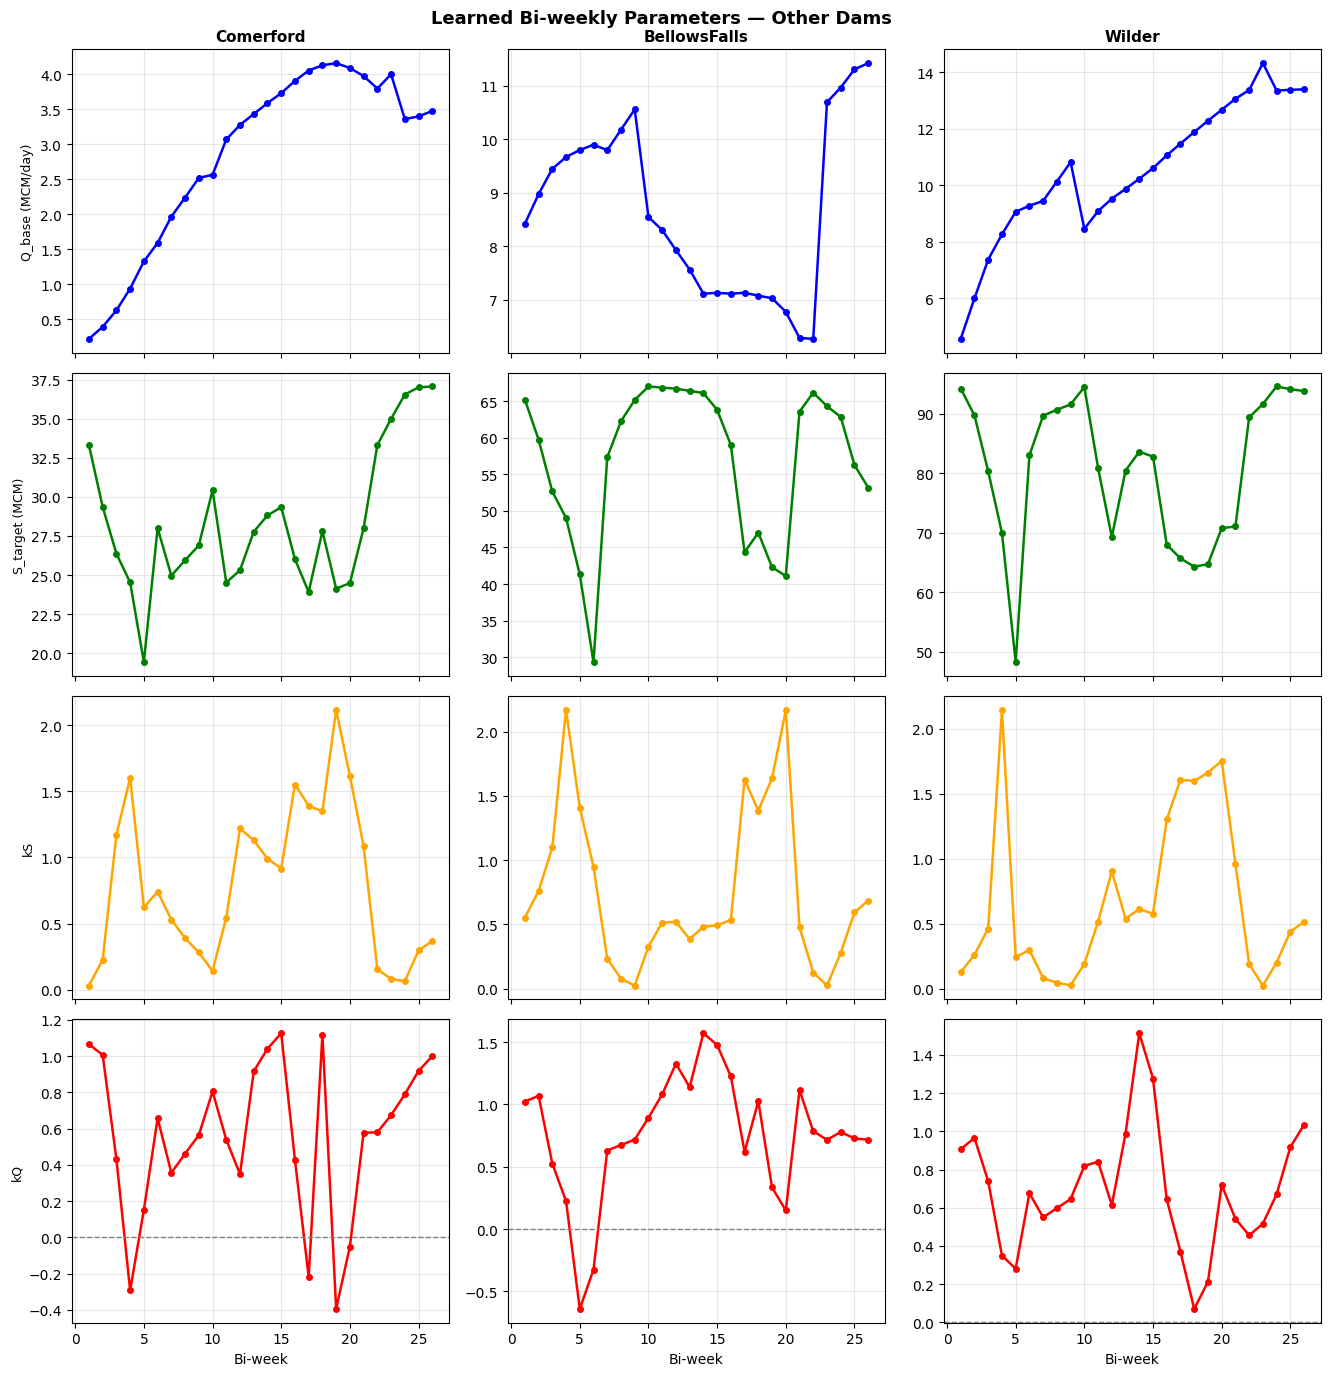

In [9]:
import jax.nn as jnn

biweeks = np.arange(1, 27)
param_labels = ["Q_base (MCM/day)", "S_target (MCM)", "kS", "kQ"]
colors = ["blue", "green", "orange", "red"]

fig, axes = plt.subplots(4, n, figsize=(4.5 * n, 14), sharex=True)

for col, (dam_name, r) in enumerate(results.items()):
    p = r["best_params"]
    Smax = r["Smax"]

    param_curves = [
        np.array(jnn.softplus(p[0:26])),
        np.array(jnn.sigmoid(p[26:52])) * Smax,
        np.array(jnn.softplus(p[52:78])),
        np.array(np.tanh(p[78:104])) * 2.0,
    ]

    for row, (curve, label, color) in enumerate(zip(param_curves, param_labels, colors)):
        ax = axes[row, col]
        ax.plot(biweeks, curve, "o-", color=color, linewidth=1.8, markersize=4)
        if row == 3:
            ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
        if row == 0:
            ax.set_title(dam_name, fontsize=11, fontweight="bold")
        if row == 3:
            ax.set_xlabel("Bi-week")
        ax.grid(alpha=0.3)

plt.suptitle("Learned Bi-weekly Parameters — Other Dams",
             fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(FIGURE_DIR / "other_dams_learned_params.png", dpi=150)
plt.show()

## 6. Loss Convergence — All Dams

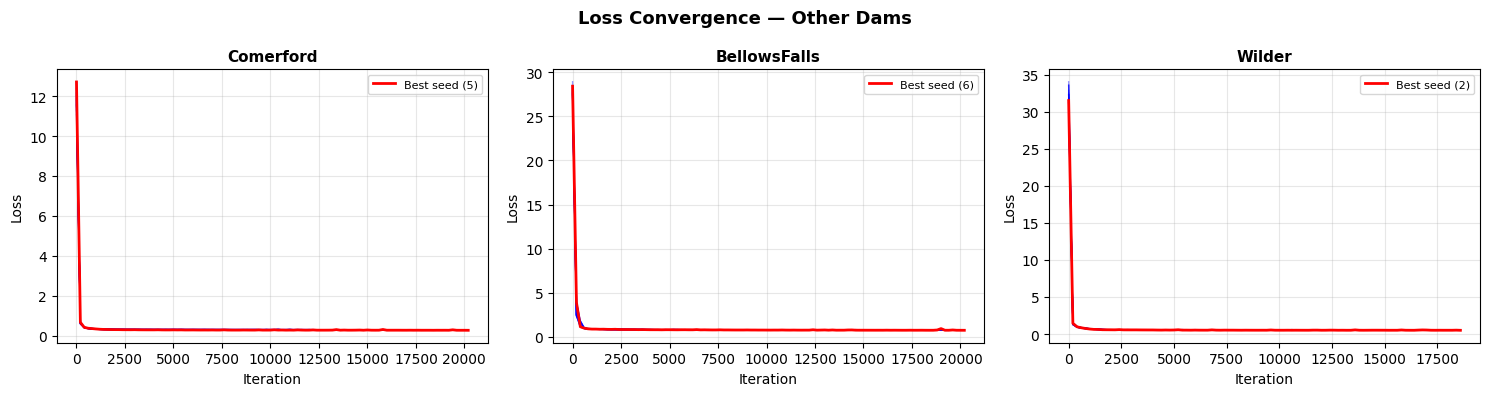

In [8]:
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

if n == 1:
    axes = [axes]

for ax, (dam_name, r) in zip(axes, results.items()):
    best_seed = r["summary"]["best_seed"]
    for run in r["all_runs"]:
        iters = np.arange(len(run["loss_history"])) * 200
        ax.plot(iters, np.array(run["loss_history"]), color="blue", alpha=0.4, linewidth=1)
    best_run = r["all_runs"][best_seed]
    iters = np.arange(len(best_run["loss_history"])) * 200
    ax.plot(iters, np.array(best_run["loss_history"]),
            color="red", linewidth=2, label=f"Best seed ({best_seed})")
    ax.set_title(dam_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Loss Convergence — Other Dams", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(FIGURE_DIR / "other_dams_loss_curves.png", dpi=150)
plt.show()

## 7. Learned Seasonal Target Storage Across Seeds — All Dams


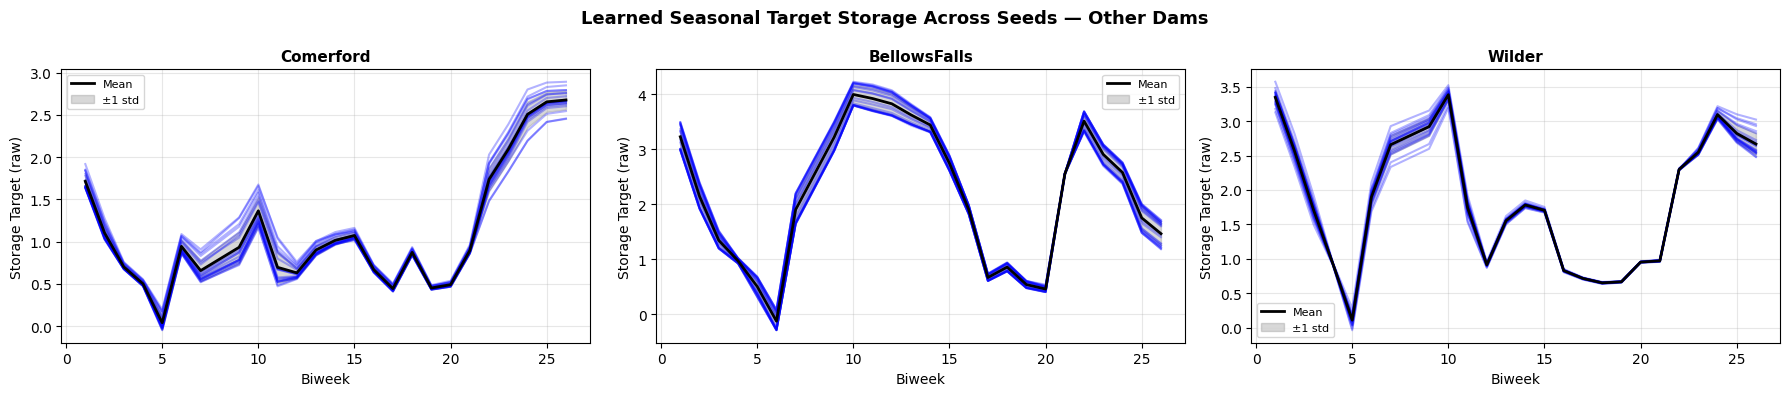

In [12]:
biweeks = np.arange(1, 27)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), sharey=False)

if n == 1:
    axes = [axes]

for ax, (dam_name, r) in zip(axes, results.items()):
    Smax = r["Smax"]
    params_all = np.array([np.array(run["params_final"]) for run in r["all_runs"]])
    S_target_all = params_all[:, 26:52]  # raw starget values

    # All seeds (thin, blue)
    for i in range(S_target_all.shape[0]):
        ax.plot(biweeks, S_target_all[i], color="blue", alpha=0.3)

    # Mean and std
    mean_curve = S_target_all.mean(axis=0)
    std_curve = S_target_all.std(axis=0)
    ax.plot(biweeks, mean_curve, color="black", linewidth=2, label="Mean")
    ax.fill_between(biweeks,
                    mean_curve - std_curve,
                    mean_curve + std_curve,
                    color="gray", alpha=0.3, label="±1 std")

    ax.set_title(dam_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Biweek")
    ax.set_ylabel("Storage Target (raw)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Learned Seasonal Target Storage Across Seeds — Other Dams",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
